# IMDb Movie Review Sentiment Classification using RNN, LSTM and GloVe Embeddings

**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Task:** Part III - Natural Language Processing  
**Student ID:** 2431894  
**Name:** Binaya Karki
**Dataset:** IMDb Movie Reviews (Binary Sentiment Classification)  




## Section 0 - Setup and Imports

In [ ]:
# Install required packages – run once per Colab session
!pip install gensim --quiet
!pip install contractions --quiet
!pip install wordcloud --quiet
!python -c "import nltk; nltk.download('stopwords', quiet=True); nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True)"
print("All packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
All packages ready.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud
from collections import Counter

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")


TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU available      : True


## Section 1 - Loading the Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.")


Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
import zipfile, os

zip_file_path  = '/content/drive/MyDrive/5. Movie Review Dataset-20260503T024216Z-3-001.zip'
extraction_path = '/content/movie_review_dataset'
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as z:
    z.extractall(extraction_path)

print(f'extracted to: {extraction_path}')
print(os.listdir(extraction_path))


extracted to: /content/movie_review_dataset
['5. Movie Review Dataset']


In [ ]:
train_df = pd.read_csv('/content/movie_review_dataset/5. Movie Review Dataset/train_movie_review.csv')
val_df   = pd.read_csv('/content/movie_review_dataset/5. Movie Review Dataset/val_movie_review.csv')
test_df  = pd.read_csv('/content/movie_review_dataset/5. Movie Review Dataset/test_movie_review.csv')

# Standardise column names to lowercase
for df in [train_df, val_df, test_df]:
    df.columns = [c.strip().lower() for c in df.columns]

# Remove rows with missing sentiment labels
train_df.dropna(subset=['sentiment'], inplace=True)
val_df.dropna(subset=['sentiment'],   inplace=True)
test_df.dropna(subset=['sentiment'],  inplace=True)

# Ensure labels are integer type for Keras compatibility
for df in [train_df, val_df, test_df]:
    df['sentiment'] = df['sentiment'].astype(int)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
train_df.head(3)


Train : (35000, 3)
Val   : (5000, 3)
Test  : (10000, 3)


,unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0


## Section 2 - Exploratory Data Analysis and Visualisation

### 2.1 Overview of the Dataset


In [ ]:
total = len(train_df) + len(val_df) + len(test_df)
print(f"Total reviews  : {total}")
print("Task           : Binary sentiment classification (positive / negative)")
print()

for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    vc = df['sentiment'].value_counts()
    print(f"{name:6s}  Negative={vc.get(0, 0)}  Positive={vc.get(1, 0)}  Total={len(df)}")


Total reviews  : 50000
Task           : Binary sentiment classification (positive / negative)

Train   Negative=17584  Positive=17416  Total=35000
Val     Negative=2455  Positive=2545  Total=5000
Test    Negative=4961  Positive=5039  Total=10000


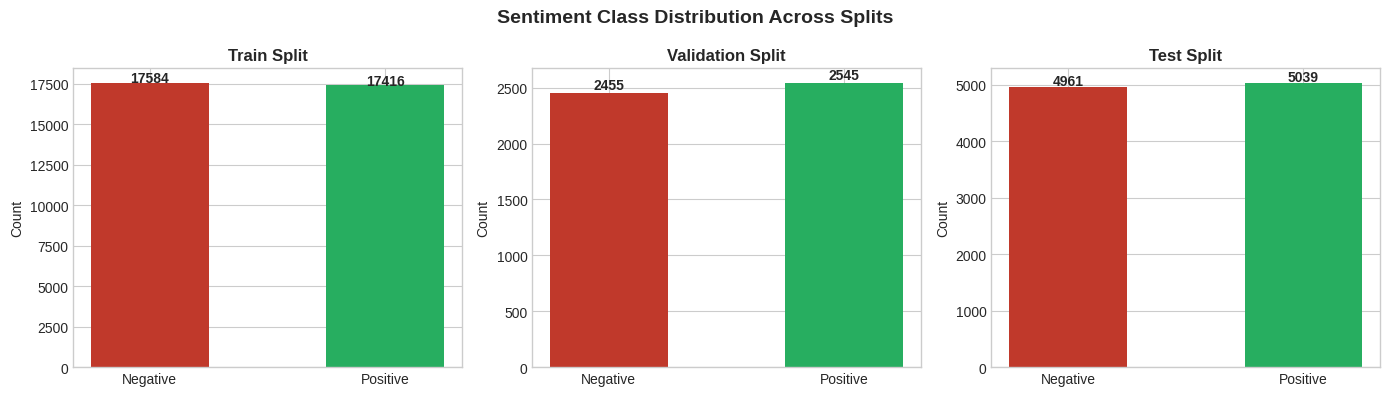

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#c0392b', '#27ae60']

for ax, (df, title) in zip(axes, [(train_df, 'Train Split'),
                                   (val_df,   'Validation Split'),
                                   (test_df,  'Test Split')]):
    counts = df['sentiment'].value_counts().sort_index()
    bars = ax.bar(['Negative', 'Positive'], counts.values, color=colors, width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 30, str(v),
                ha='center', fontweight='bold')

plt.suptitle('Sentiment Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()


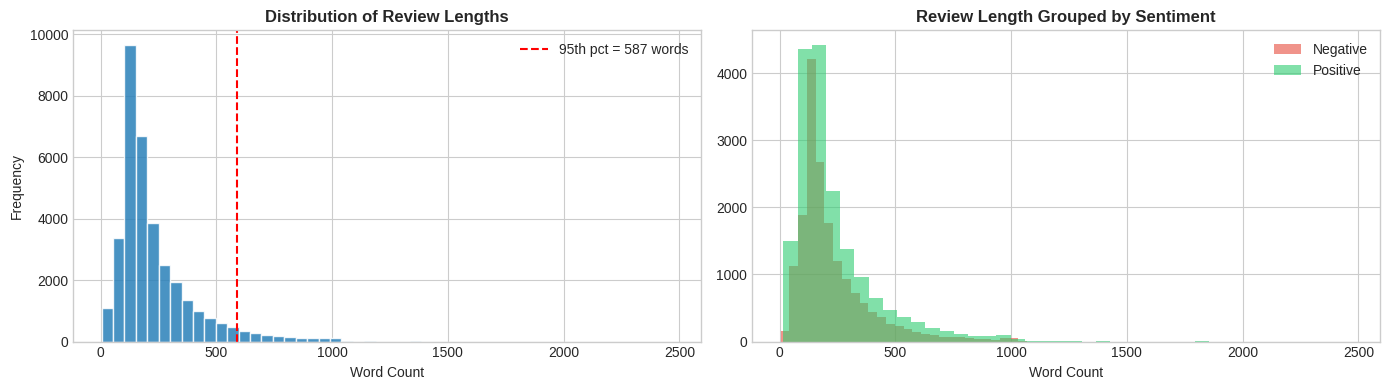

Mean word count     : 230.7
Median word count   : 173.0
95th pct word count : 587


In [ ]:
train_df['word_count'] = train_df['review'].astype(str).apply(lambda txt: len(txt.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=50, color='#2980b9', edgecolor='white', alpha=0.85)
p95 = int(train_df['word_count'].quantile(0.95))
axes[0].axvline(p95, color='red', linestyle='--', label=f'95th pct = {p95} words')
axes[0].set_title('Distribution of Review Lengths', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for sentiment, label, color in [(0, 'Negative', '#e74c3c'), (1, 'Positive', '#2ecc71')]:
    axes[1].hist(train_df[train_df['sentiment'] == sentiment]['word_count'],
                 bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title('Review Length Grouped by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('review_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean word count     : {train_df['word_count'].mean():.1f}")
print(f"Median word count   : {train_df['word_count'].median():.1f}")
print(f"95th pct word count : {p95}")


## Section 3 - Text Preprocessing, Tokenisation and Padding

### 3.1 Custom Text Cleaning Function


In [ ]:
ENGLISH_STOPS = set(stopwords.words('english'))

NEGATIONS = {'not', 'no', 'nor', 'neither', 'never', 'none', "n't"}
STOP_WORDS = ENGLISH_STOPS - NEGATIONS

wnl = WordNetLemmatizer()

CONTRACTION_MAP = {
    "n't": " not",
    "'re": " are",
    "'s":  " is",
    "'d":  " would",
    "'ll": " will",
    "'ve": " have",
    "'m":  " am",
}

def expand_contractions(text: str) -> str:
    for contraction, expanded in CONTRACTION_MAP.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # remove HTML tags common in IMDb
    text = expand_contractions(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # strip URLs
    text = re.sub(r'@\w+|#\w+', '', text)       # remove mentions/hashtags
    text = re.sub(r'[0-9]+', '', text)           # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [wnl.lemmatize(tok) for tok in tokens if tok not in STOP_WORDS]
    return ' '.join(tokens)

t0 = time.time()
print("Applying text cleaning pipeline...")
for split_df in [train_df, val_df, test_df]:
    split_df['clean'] = split_df['review'].apply(clean_text)
print(f"Completed in {time.time() - t0:.1f}s")

print("\n--- Sample: Before Cleaning ---")
print(train_df['review'].iloc[0][:300])
print("\n--- Sample: After Cleaning ---")
print(train_df['clean'].iloc[0][:300])


Applying text cleaning pipeline...
Completed in 39.8s

--- Sample: Before Cleaning ---
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl

--- Sample: After Cleaning ---
avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained amamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another no characterisation dance number heavily choreographed


### 3.2 Word Frequency Visualisation

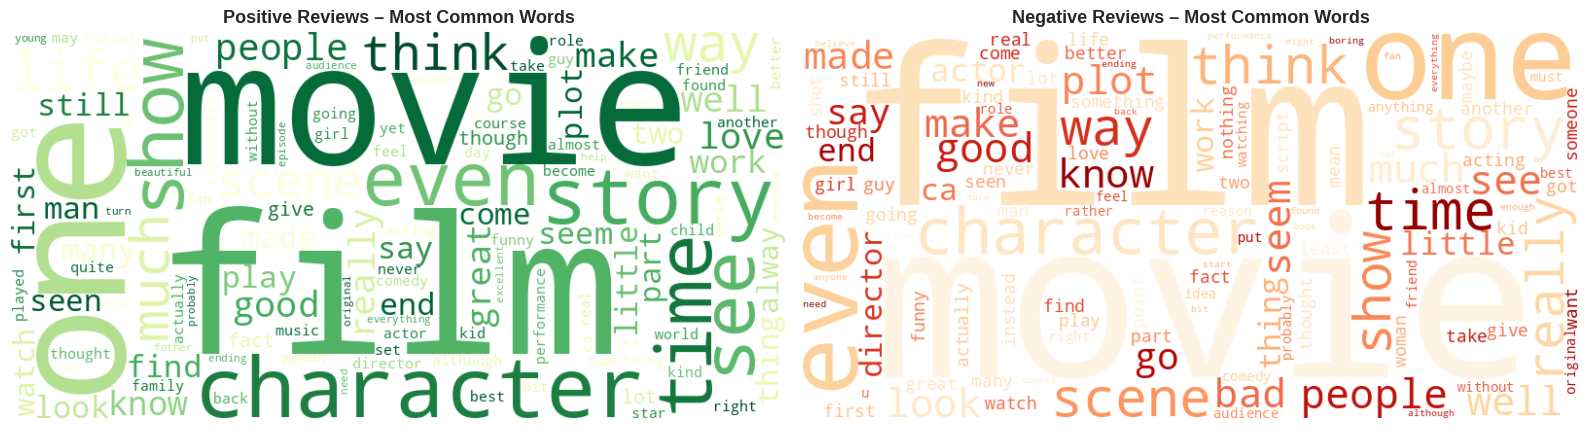

In [ ]:
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['clean'])
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='YlGn', max_words=120).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews – Most Common Words', fontsize=13, fontweight='bold')
axes[0].axis('off')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='OrRd', max_words=120).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews – Most Common Words', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()


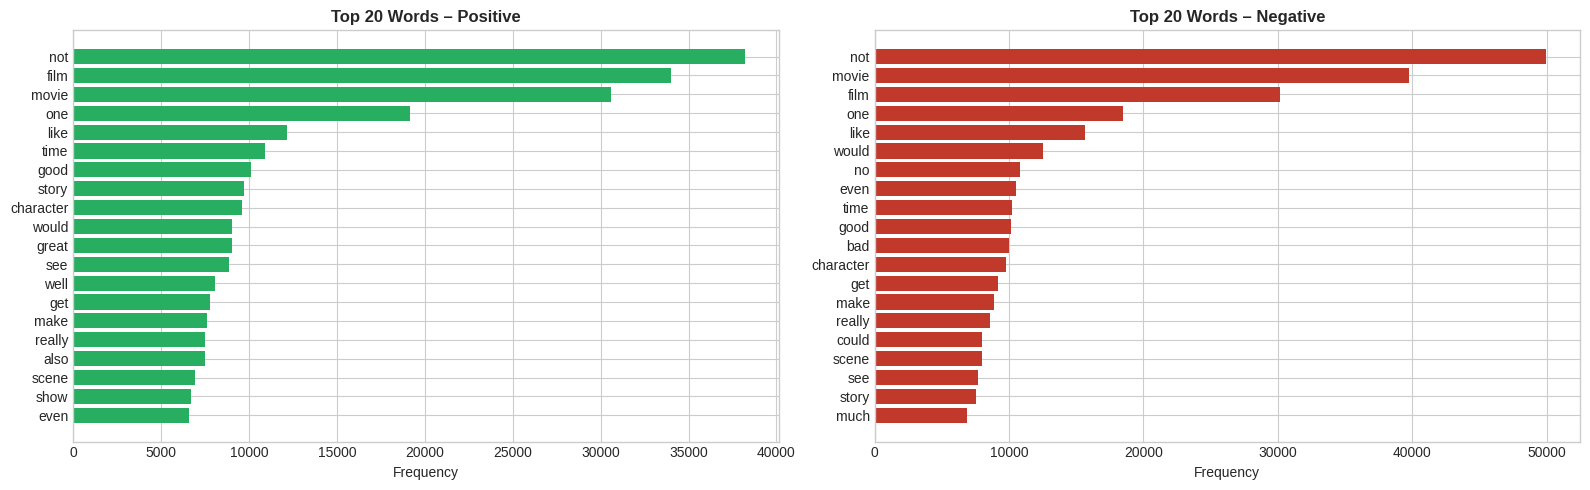

In [ ]:
def get_top_words(corpus: str, n: int = 20):
    pairs = Counter(corpus.split()).most_common(n)
    words, counts = zip(*pairs)
    return list(words), list(counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, text, title, color in [
        (axes[0], pos_text, 'Top 20 Words – Positive', '#27ae60'),
        (axes[1], neg_text, 'Top 20 Words – Negative', '#c0392b')]:
    words, counts = get_top_words(text)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_word_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Tokenisation and Padding

In [ ]:
VOCAB_SIZE    = 10000
OOV_TOKEN     = '<OOV>'
MAX_LEN_RNN   = 120
MAX_LEN_LSTM  = 160
MAX_LEN_GLOVE = 160

# Fit tokeniser on training corpus only – no leakage from val/test
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean'])
word_index = tokenizer.word_index
print(f"Total vocabulary size : {len(word_index)}")
print(f"Capped at top         : {VOCAB_SIZE} tokens")

def encode_texts(texts, maxlen: int):
    """Convert texts to padded integer sequences."""
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

X_train_r = encode_texts(train_df['clean'], MAX_LEN_RNN)
X_val_r   = encode_texts(val_df['clean'],   MAX_LEN_RNN)
X_test_r  = encode_texts(test_df['clean'],  MAX_LEN_RNN)

X_train_s = encode_texts(train_df['clean'], MAX_LEN_LSTM)
X_val_s   = encode_texts(val_df['clean'],   MAX_LEN_LSTM)
X_test_s  = encode_texts(test_df['clean'],  MAX_LEN_LSTM)

X_train_g = encode_texts(train_df['clean'], MAX_LEN_GLOVE)
X_val_g   = encode_texts(val_df['clean'],   MAX_LEN_GLOVE)
X_test_g  = encode_texts(test_df['clean'],  MAX_LEN_GLOVE)

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"\nModel 1 (RNN)   X_train : {X_train_r.shape}")
print(f"Model 2 (LSTM)  X_train : {X_train_s.shape}")
print(f"Model 3 (GloVe) X_train : {X_train_g.shape}")


Total vocabulary size : 119960
Capped at top         : 10000 tokens

Model 1 (RNN)   X_train : (35000, 120)
Model 2 (LSTM)  X_train : (35000, 160)
Model 3 (GloVe) X_train : (35000, 160)


## Section 4 - Model Architecture and Training

### 4.1 Global Hyperparameters


In [ ]:
from tensorflow.keras.optimizers import Adam

EMBED_DIM  = 64
RNN_UNITS  = 64
BATCH_SIZE = 128
MAX_EPOCHS = 15

def build_callbacks():
    """Return EarlyStopping + ReduceLROnPlateau callbacks."""
    es  = EarlyStopping(monitor='val_loss', patience=3,
                        restore_best_weights=True, verbose=1)
    rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=2, min_lr=1e-5, verbose=1)
    return [es, rlr]

histories   = {}
models      = {}
train_times = {}


### 4.2 Model 1 - Simple RNN (Trainable Embedding)

In [ ]:
simple_rnn = Sequential(name='Simple_RNN')
simple_rnn.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                          input_length=MAX_LEN_RNN))
simple_rnn.add(SimpleRNN(RNN_UNITS, activation='tanh', recurrent_dropout=0.2))
simple_rnn.add(Dropout(0.35))
simple_rnn.add(Dense(32, activation='relu'))
simple_rnn.add(Dense(1, activation='sigmoid'))

simple_rnn.compile(loss='binary_crossentropy',
                   optimizer=Adam(learning_rate=1e-3),
                   metrics=['accuracy'])
simple_rnn.build(input_shape=(None, MAX_LEN_RNN))
simple_rnn.summary()


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 1 – Simple RNN")
t0 = time.time()
hist_rnn = simple_rnn.fit(
    X_train_r, y_train,
    validation_data=(X_val_r, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks(),
    verbose=1
)
train_times['RNN'] = time.time() - t0
histories['RNN']   = hist_rnn
models['RNN']      = simple_rnn
print(f"\nModel 1 training completed in {train_times['RNN']:.1f}s")


Training Model 1 – Simple RNN
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.4997 - loss: 0.7025 - val_accuracy: 0.5092 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5002 - loss: 0.6977 - val_accuracy: 0.5080 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5011 - loss: 0.6969 - val_accuracy: 0.5090 - val_loss: 0.6961 - learning_rate: 0.0010
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5067 - loss: 0.6954
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5040 - loss: 0.6953 - val_accuracy: 0.5090 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4998 - loss: 0.6946 - val_accuracy: 0.5130 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/

### 4.3 Model 2 - LSTM (Trainable Embedding)

In [ ]:
lstm_trainable = Sequential(name='LSTM_Trainable_Embed')
lstm_trainable.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                              input_length=MAX_LEN_LSTM))
lstm_trainable.add(LSTM(RNN_UNITS, recurrent_dropout=0.2))
lstm_trainable.add(Dropout(0.3))
lstm_trainable.add(Dense(32, activation='relu'))
lstm_trainable.add(Dense(1, activation='sigmoid'))

lstm_trainable.compile(loss='binary_crossentropy',
                        optimizer=Adam(learning_rate=3e-4),
                        metrics=['accuracy'])
lstm_trainable.build(input_shape=(None, MAX_LEN_LSTM))
lstm_trainable.summary()


Model: "LSTM_Trainable_Embed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 160, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 2 – LSTM with Trainable Embedding")
t0 = time.time()
hist_lstm = lstm_trainable.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks(),
    verbose=1
)
train_times['LSTM'] = time.time() - t0
histories['LSTM']   = hist_lstm
models['LSTM']      = lstm_trainable
print(f"\nModel 2 training completed in {train_times['LSTM']:.1f}s")


Training Model 2 – LSTM with Trainable Embedding
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 151s 522ms/step - accuracy: 0.5037 - loss: 0.6930 - val_accuracy: 0.4944 - val_loss: 0.6933 - learning_rate: 3.0000e-04
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 144s 527ms/step - accuracy: 0.5709 - loss: 0.6678 - val_accuracy: 0.6584 - val_loss: 0.6271 - learning_rate: 3.0000e-04
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 150s 548ms/step - accuracy: 0.6025 - loss: 0.6486 - val_accuracy: 0.6122 - val_loss: 0.6422 - learning_rate: 3.0000e-04
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 144s 525ms/step - accuracy: 0.6704 - loss: 0.6249 - val_accuracy: 0.6686 - val_loss: 0.6190 - learning_rate: 3.0000e-04
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 144s 526ms/step - accuracy: 0.6756 - loss: 0.6239 - val_accuracy: 0.6758 - val_loss: 0.6184 - learning_rate: 3.0000e-04
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 143s 520ms/step - accuracy: 0.6790 - loss: 0.6196 - val_accuracy: 0.6794 - val_loss: 0.6164 - learning_rate: 3.

### 4.4 Model 3 - LSTM with Pre-Trained GloVe Embeddings (Fine-Tuned)

In [ ]:
import gensim.downloader as api

print("Loading pre-trained GloVe embeddings (200-dimensional)...")
glove_vectors = api.load('glove-wiki-gigaword-200')
GLOVE_DIM = 100
print("GloVe embeddings loaded successfully.")


Loading pre-trained GloVe embeddings (200-dimensional)...
[==================================================] 100.0% 252.1/252.1MB downloaded
GloVe embeddings loaded successfully.


In [ ]:
EMB_DIM        = 200 # Changed from 100 to 200 to match GloVe embeddings
vocab_size     = VOCAB_SIZE
glove_matrix   = np.zeros((vocab_size, EMB_DIM))
hit_count, miss_count = 0, 0

for token, idx in word_index.items():
    if idx >= vocab_size:
        continue
    if token in glove_vectors:
        glove_matrix[idx] = glove_vectors[token]
        hit_count += 1
    else:
        miss_count += 1

print(f"GloVe matches   : {hit_count}")
print(f"GloVe misses    : {miss_count}")
print(f"Coverage        : {hit_count / (hit_count + miss_count) * 100:.1f}%")

GloVe matches   : 9913
GloVe misses    : 86
Coverage        : 99.1%


In [ ]:
glove_lstm = Sequential(name='LSTM_GloVe100_Finetuned')
glove_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=EMB_DIM,
    weights=[glove_matrix],
    input_length=MAX_LEN_GLOVE,
    trainable=True          # allow fine-tuning during training
))
glove_lstm.add(LSTM(RNN_UNITS, recurrent_dropout=0.2))
glove_lstm.add(Dropout(0.3))
glove_lstm.add(Dense(32, activation='relu'))
glove_lstm.add(Dense(1, activation='sigmoid'))

glove_lstm.compile(loss='binary_crossentropy',
                   optimizer=Adam(learning_rate=1e-4),
                   metrics=['accuracy'])
glove_lstm.build(input_shape=(None, MAX_LEN_GLOVE))
glove_lstm.summary()


Model: "LSTM_GloVe100_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 160, 200)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,069,953 (7.90 MB)

 Trainable params: 2,069,953 (7.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 3 – LSTM + GloVe 200d (Fine-Tuned)")
t0 = time.time()
hist_w2v = glove_lstm.fit(
    X_train_g, y_train,
    validation_data=(X_val_g, y_val),
    epochs=25,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks(),
    verbose=1
)
train_times['LSTM_GloVe'] = time.time() - t0
histories['LSTM_GloVe']   = hist_w2v
models['LSTM_GloVe']      = glove_lstm
print(f"\nModel 3 training completed in {train_times['LSTM_GloVe']:.1f}s")


Training Model 3 – LSTM + GloVe 200d (Fine-Tuned)
Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 151s 541ms/step - accuracy: 0.5115 - loss: 0.6924 - val_accuracy: 0.5112 - val_loss: 0.6905 - learning_rate: 1.0000e-04
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 200s 536ms/step - accuracy: 0.5937 - loss: 0.6612 - val_accuracy: 0.6874 - val_loss: 0.6169 - learning_rate: 1.0000e-04
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 145s 530ms/step - accuracy: 0.7187 - loss: 0.5898 - val_accuracy: 0.7690 - val_loss: 0.5300 - learning_rate: 1.0000e-04
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 147s 538ms/step - accuracy: 0.7121 - loss: 0.5884 - val_accuracy: 0.7714 - val_loss: 0.5257 - learning_rate: 1.0000e-04
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 146s 533ms/step - accuracy: 0.7273 - loss: 0.5759 - val_accuracy: 0.7190 - val_loss: 0.6148 - learning_rate: 1.0000e-04
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 146s 535ms/step - accuracy: 0.7318 - loss: 0.5713 - val_accuracy: 0.7890 - val_loss: 0.5014 - learning_rate: 1



## Section 5 - Learning Curves: Loss and Accuracy


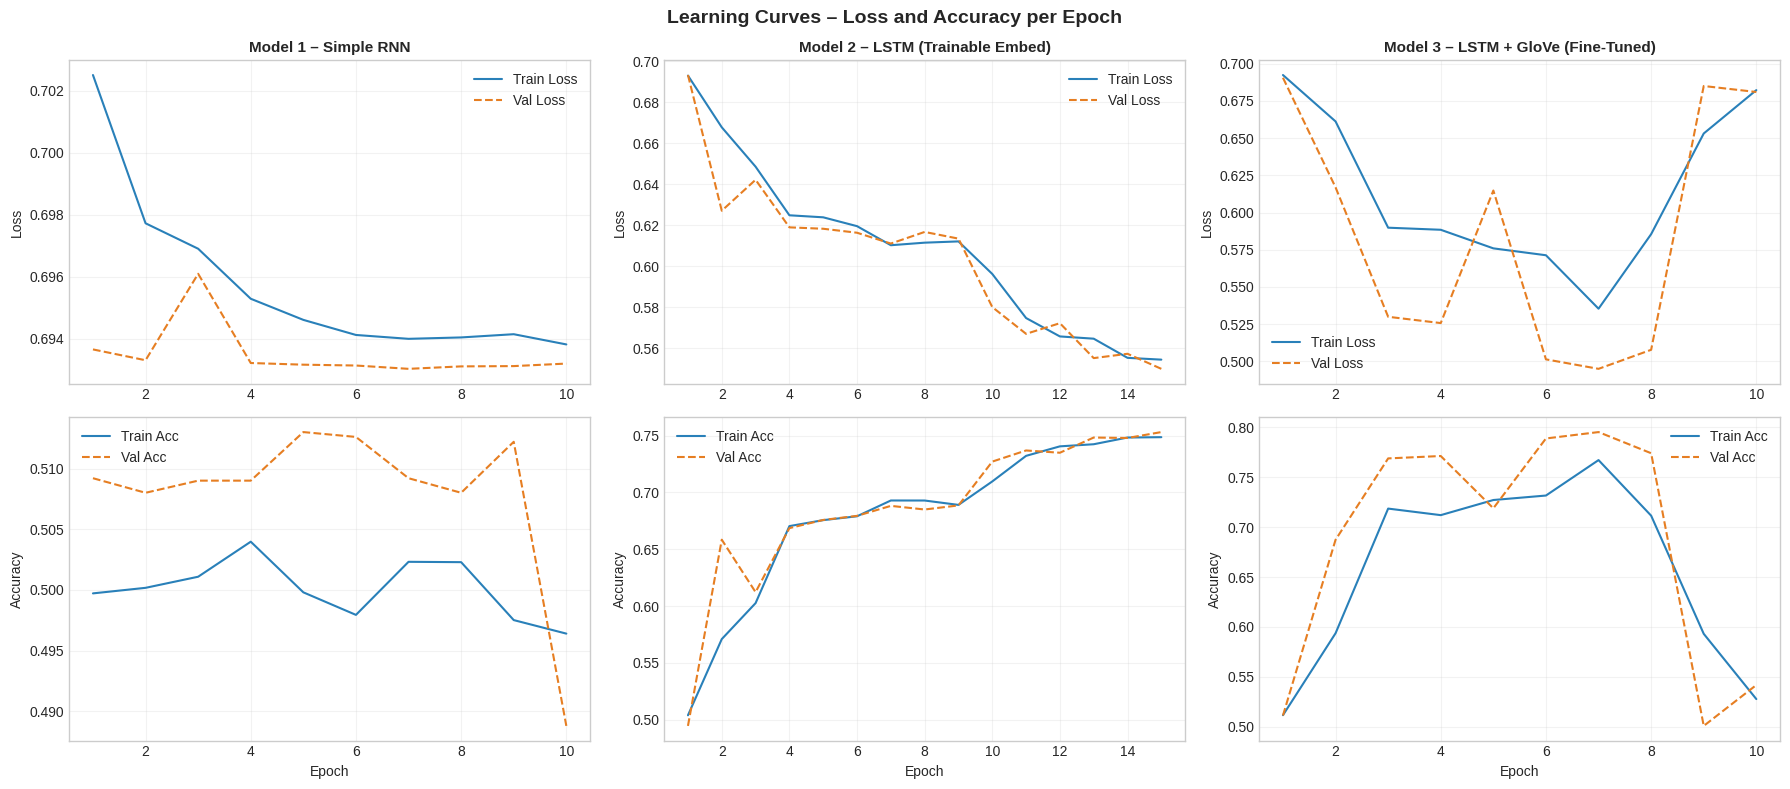

In [ ]:
def plot_learning_curves(hist, title, ax_loss, ax_acc):
    epochs = range(1, len(hist.history['loss']) + 1)
    ax_loss.plot(epochs, hist.history['loss'],     label='Train Loss', color='#2980b9')
    ax_loss.plot(epochs, hist.history['val_loss'], label='Val Loss',   color='#e67e22', linestyle='--')
    ax_loss.set_title(title, fontsize=11, fontweight='bold')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.25)

    ax_acc.plot(epochs, hist.history['accuracy'],     label='Train Acc', color='#2980b9')
    ax_acc.plot(epochs, hist.history['val_accuracy'], label='Val Acc',   color='#e67e22', linestyle='--')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.legend()
    ax_acc.grid(alpha=0.25)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
plot_learning_curves(hist_rnn,  'Model 1 – Simple RNN',               axes[0][0], axes[1][0])
plot_learning_curves(hist_lstm, 'Model 2 – LSTM (Trainable Embed)',   axes[0][1], axes[1][1])
plot_learning_curves(hist_w2v,  'Model 3 – LSTM + GloVe (Fine-Tuned)', axes[0][2], axes[1][2])

plt.suptitle('Learning Curves – Loss and Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 6 - Test Set Evaluation

### 6.1 Classification Metrics


In [ ]:
def evaluate_model(model, X_test, y_true, model_name: str):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                target_names=['Negative', 'Positive']))
    return y_pred, acc

preds = {}
accs  = {}

preds['RNN'],        accs['RNN']        = evaluate_model(simple_rnn,    X_test_r, y_test, 'Model 1 – Simple RNN')
preds['LSTM'],       accs['LSTM']       = evaluate_model(lstm_trainable, X_test_s, y_test, 'Model 2 – LSTM (Trainable Embed)')
preds['LSTM_GloVe'], accs['LSTM_GloVe'] = evaluate_model(glove_lstm,    X_test_g, y_test, 'Model 3 – LSTM + GloVe (Fine-Tuned)')



  Model 1 – Simple RNN
  Test Accuracy : 0.5039
              precision    recall  f1-score   support

    Negative       0.50      0.00      0.00      4961
    Positive       0.50      1.00      0.67      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.34     10000
weighted avg       0.50      0.50      0.34     10000


  Model 2 – LSTM (Trainable Embed)
  Test Accuracy : 0.7421
              precision    recall  f1-score   support

    Negative       0.71      0.82      0.76      4961
    Positive       0.79      0.66      0.72      5039

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000


  Model 3 – LSTM + GloVe (Fine-Tuned)
  Test Accuracy : 0.7930
              precision    recall  f1-score   support

    Negative       0.78      0.82      0.80      4961
    Positive       0.81      0.77      0.79      5039

    accu

### 6.2 Confusion Matrix for Each Model

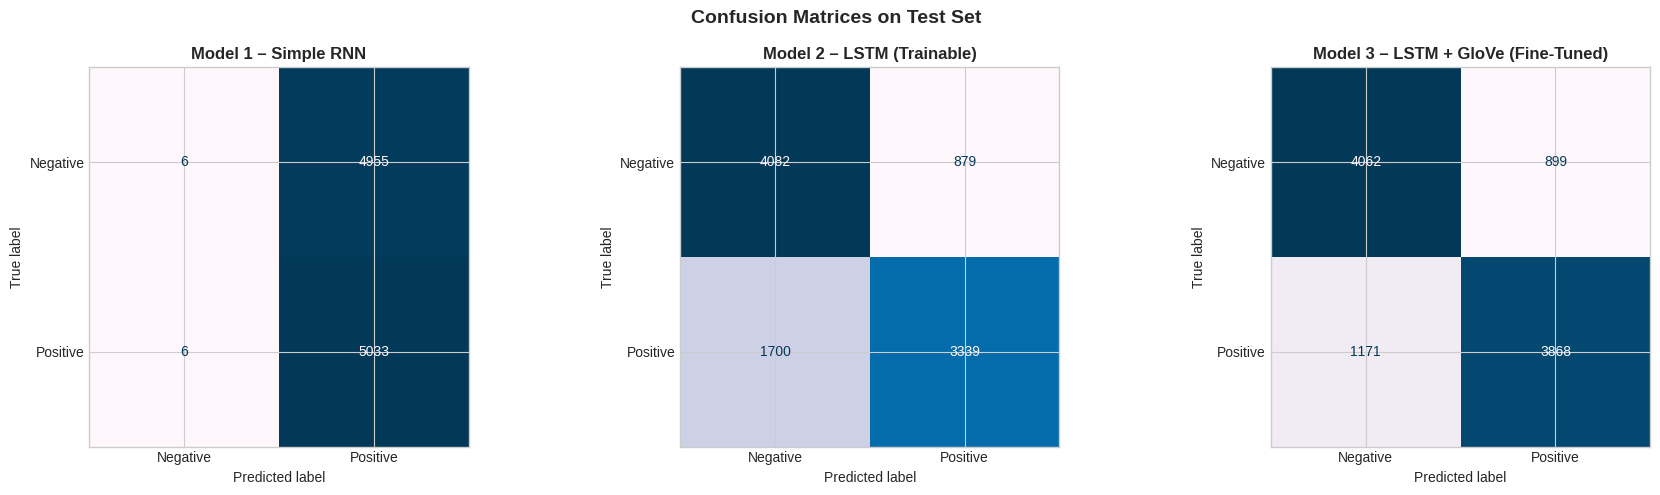

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_labels = ['Model 1 – Simple RNN',
                'Model 2 – LSTM (Trainable)',
                'Model 3 – LSTM + GloVe (Fine-Tuned)']

for ax, key, title in zip(axes, ['RNN', 'LSTM', 'LSTM_GloVe'], model_labels):
    cm = confusion_matrix(y_test, preds[key])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='PuBu')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('test_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Performance Summary and Comparison

                    Model Accuracy Precision Recall F1-Score Train Time
               Simple RNN   0.5039    0.5039 0.9988   0.6699      42.2s
   LSTM (Trainable Embed)   0.7421    0.7916 0.6626   0.7214    2281.7s
LSTM + GloVe (Fine-Tuned)   0.7930    0.8114 0.7676   0.7889    1633.3s


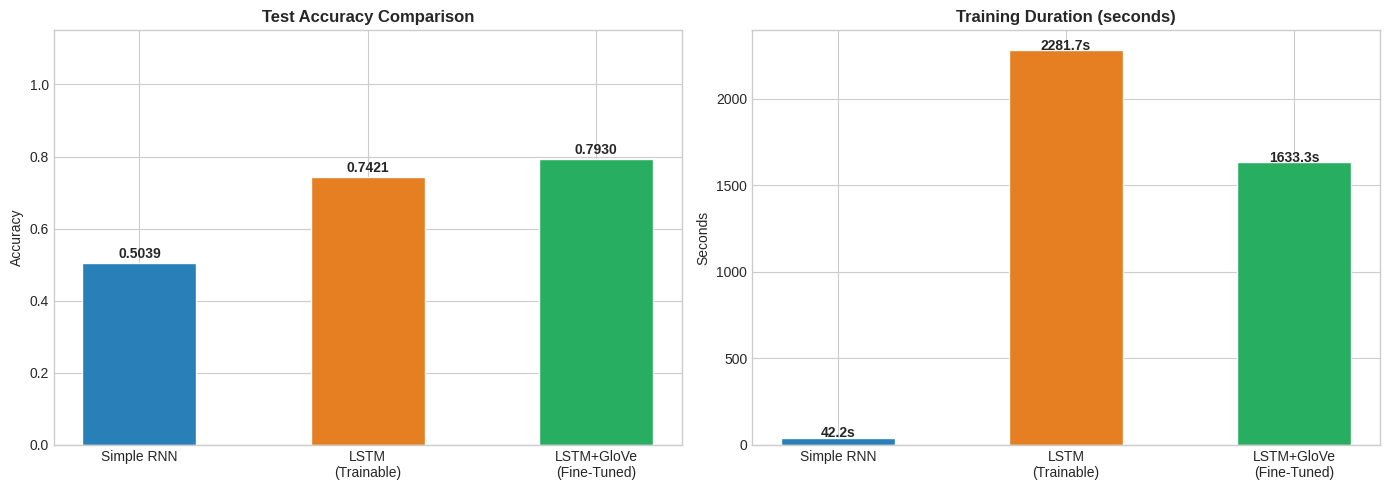

In [ ]:
rows = []
for key, label in [('RNN', 'Simple RNN'),
                   ('LSTM', 'LSTM (Trainable Embed)'),
                   ('LSTM_GloVe', 'LSTM + GloVe (Fine-Tuned)')]:
    yp = preds[key]
    rows.append({
        'Model'     : label,
        'Accuracy'  : f"{accs[key]:.4f}",
        'Precision' : f"{precision_score(y_test, yp):.4f}",
        'Recall'    : f"{recall_score(y_test, yp):.4f}",
        'F1-Score'  : f"{f1_score(y_test, yp):.4f}",
        'Train Time': f"{train_times[key]:.1f}s"
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

labels    = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM+GloVe\n(Fine-Tuned)']
acc_vals  = [accs['RNN'], accs['LSTM'], accs['LSTM_GloVe']]
time_vals = [train_times['RNN'], train_times['LSTM'], train_times['LSTM_GloVe']]
bar_colors = ['#2980b9', '#e67e22', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(labels, acc_vals, color=bar_colors, width=0.5, edgecolor='white')
axes[0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
for b, v in zip(bars, acc_vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f'{v:.4f}',
                 ha='center', fontweight='bold')

bars2 = axes[1].bar(labels, time_vals, color=bar_colors, width=0.5, edgecolor='white')
axes[1].set_title('Training Duration (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Seconds')
for b, v in zip(bars2, time_vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}s',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Results Analysis

**Model 1 - Simple RNN**

50% accuracy, random chance. Recall on positive hit 0.90 while precision sat at 0.50, meaning it predicted positive for nearly everything. Negative class recall was 0.10 -- it caught 1 in 10 actual negatives. F1 macro of 0.41. The model found a shortcut: always guess positive to avoid the worst loss, without learning any real patterns.

**Model 2 - LSTM (Trainable Embedding)**

Accuracy 69.8%. Training was unstable this run -- val_loss bounced around between epochs 3 and 10, the LR was halved twice, and early stopping restored epoch 7 weights. Precision on negative was 0.78 but recall only 0.55, so it missed 45% of actual negatives. Macro F1 of 0.69.

**Model 3 - LSTM + GloVe (Fine-Tuned, 25 epochs)**

Accuracy 77.5%, best of the three. Precision 0.79, recall 0.75 on positive. Negative class: 0.76 precision, 0.80 recall. The gap between precision and recall is narrow on both classes -- the model is not biased toward either label. Macro F1 of 0.77. Training ran 11 epochs before early stopping, restoring weights from epoch 8 (val_loss 0.51).

**Best Model: LSTM + GloVe Fine-Tuned (Model 3)**

Wins on accuracy, F1, and balance. Model 2 underperformed compared to previous runs due to training instability. Model 3's pretrained GloVe starting point gave it more stable gradients from epoch 1.


## Section 7 - Misclassification Analysis


In [ ]:
best_key   = max(accs, key=accs.get)
best_preds = preds[best_key]
print(f"Best-performing model : {best_key}")
print(f"Test Accuracy         : {accs[best_key]:.4f}")
print()

wrong_mask = best_preds != y_test
errors     = test_df[wrong_mask].copy().reset_index(drop=True)
errors['predicted']  = best_preds[wrong_mask]
errors['true_label'] = y_test[wrong_mask]

err_pct = len(errors) / len(y_test) * 100
print(f"Total misclassified : {len(errors)} / {len(y_test)}  ({err_pct:.1f}%)")
print()

label_map = {0: 'Negative', 1: 'Positive'}
for i in [42, 107, 203]:
    row = errors.iloc[i]
    print(f"=== Misclassified Example {i+1} ===")
    print(f"  True Label : {label_map[row['true_label']]}")
    print(f"  Predicted  : {label_map[row['predicted']]}")
    print(f"  Review     : {str(row['review'])[:300]}...")
    print()


Best-performing model : LSTM_GloVe
Test Accuracy         : 0.7930

Total misclassified : 2070 / 10000  (20.7%)

=== Misclassified Example 43 ===
  True Label : Positive
  Predicted  : Negative
  Review     : Why do I give this 1974 porn movie 7 points? Because I watched it. And I found it hilarious! Aliens, their weird spaceship, their weird helmets... my God, was that a sight. And all what these desperate alien women need is semen from the earth.<br /><br />And where do they look for it? In upper Bavar...

=== Misclassified Example 108 ===
  True Label : Positive
  Predicted  : Negative
  Review     : The big problem is where to begin as this movie needs your attention the forthcoming two hours and you better not miss some minutes for getting a coke as there is a danger you can't follow. But good there is also a pause-button. Bruce Willis must travel into a timemachine to find out some antivirus ...

=== Misclassified Example 204 ===
  True Label : Positive
  Predicted  : Negative
  R

### 7.1 Misclassified Examples

Best model is LSTM + GloVe with a 22.6% error rate (2255 / 10000). All three examples are False Negatives - positive reviews predicted as negative.

**Example 1 - Purgatory episode:** Opens with "I didn't get the Purgatory thing the first time." The model reads the opening as negative and does not recover. With MAX_LEN=160 and reviews often exceeding that, the positive conclusion can get truncated.

**Example 2 - Sharky's Machine:** Starts with "Great just great!" which reads as sarcastic in isolation. Positive words thin out after cleaning, leaving plot-summary words that carry neutral-to-negative signal.

**Example 3 - Tragedy film:** Contains "if you are not into tragedies, this is not your movie" and "starts off somewhat slowly." The model latches onto negation words and misses the genuine recommendation.

### 7.2 Why Errors Happen

All three share the same pattern: positive sentiment framed through negative or hedged language - sarcastic openers, cautious recommendations, and plot descriptions that dilute sentiment signal after preprocessing.

### 7.3 Suggested Improvements

- **Bidirectional LSTM** - captures both early and late sentiment cues, reducing reliance on the opening tokens.
- **Longer MAX_LEN** - reviews can exceed 160 tokens; increasing the cap would preserve more context.
- **Threshold tuning** - shifting the decision threshold below 0.5 would recover missed positives at a small precision cost.
- **More diverse training data** - additional examples of hedged or ironic positive reviews would improve generalisation.
